In [ ]:

!git clone https://github.com/max15189/InverseKinematics.git
import sys
sys.path.insert(0, '/content/InverseKinematics')


fatal: destination path 'InverseKinematics' already exists and is not an empty directory.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from importlib import reload
"""
Training and evaluation routines for the IK MLP.

Two modes controlled by hot_start flag:

  hot_start=False (local-Jacobian):
    q_pred = q1 + dq_pred
    loss   = ||FK(q_pred)[:3,3] - xd||

  hot_start=True:
    q_pred = model output (absolute q)
    loss   = ||p_pred - p_target|| + lambda_rot * ||R_pred - R_target||_F
    where R_target comes from FK(q1) — q1 IS the target config in this mode.
"""

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from ik.kinematics.fk import FK_batch, FK_batch_full


# ---------------------------------------------------------------------------
# Loss
# ---------------------------------------------------------------------------

def task_space_loss(
    q_pred: torch.Tensor,
    q_target: torch.Tensor,
    xd: torch.Tensor,
    hot_start: bool = False,
    lambda_rot: float = 1.0,
) -> torch.Tensor:
    """
    Args:
        q_pred:    (B, 6) predicted joint config
        q_target:  (B, 6) target joint config (q1 in the dataset)
        xd:        (B, 3) target EE position
        hot_start: if True adds Frobenius rotation loss
        lambda_rot: weight for rotation term (only used when hot_start=True)
    """
    if hot_start:
        T_pred   = FK_batch_full(q_pred)
        T_target = FK_batch_full(q_target)
        pos_loss = torch.mean(torch.norm(T_pred[:, :3, 3] - T_target[:, :3, 3], dim=1))
        rot_loss = torch.mean(torch.norm(T_pred[:, :3, :3] - T_target[:, :3, :3], dim=(1, 2)))
        return pos_loss + lambda_rot * rot_loss, pos_loss, rot_loss
    else:
        pos_loss = torch.mean(torch.norm(FK_batch(q_pred) - xd, dim=1))
        return pos_loss, pos_loss, torch.zeros(1, device=q_pred.device)


# ---------------------------------------------------------------------------
# Core train / eval loops
# ---------------------------------------------------------------------------

def train(
    model: nn.Module,
    loader: DataLoader,
    optimizer,
    device,
    scaler_Y: list,
    hot_start: bool = False,
    lambda_rot: float = 1.0,
) -> float:
    """Run one training epoch. Returns (total, pos, rot) mean losses."""
    model.train()
    Y_mean, Y_std = scaler_Y[0].to(device), scaler_Y[1].to(device)
    total_loss, pos_loss_sum, rot_loss_sum = 0.0, 0.0, 0.0

    for X, _, q1, xd in loader:
        X, q1, xd = X.to(device), q1.to(device), xd.to(device)
        optimizer.zero_grad()

        q_pred = model(X) * Y_std + Y_mean
        if not hot_start:
            q_pred = q1 + q_pred   # local-Jacobian: output is delta

        loss, pos, rot = task_space_loss(q_pred, q1, xd, hot_start, lambda_rot)
        loss.backward()
        optimizer.step()
        n = len(X)
        total_loss   += loss.item() * n
        pos_loss_sum += pos.item()  * n
        rot_loss_sum += rot.item()  * n

    N = len(loader.dataset)
    return total_loss / N, pos_loss_sum / N, rot_loss_sum / N


def evaluate(
    model: nn.Module,
    loader: DataLoader,
    device,
    scaler_Y: list,
    hot_start: bool = False,
    lambda_rot: float = 1.0,
) -> float:
    """Evaluate on a loader without gradients. Returns (total, pos, rot) mean losses."""
    model.eval()
    Y_mean, Y_std = scaler_Y[0].to(device), scaler_Y[1].to(device)
    total_loss, pos_loss_sum, rot_loss_sum = 0.0, 0.0, 0.0

    with torch.no_grad():
        for X, _, q1, xd in loader:
            X, q1, xd = X.to(device), q1.to(device), xd.to(device)

            q_pred = model(X) * Y_std + Y_mean
            if not hot_start:
                q_pred = q1 + q_pred

            loss, pos, rot = task_space_loss(q_pred, q1, xd, hot_start, lambda_rot)
            n = len(X)
            total_loss   += loss.item() * n
            pos_loss_sum += pos.item()  * n
            rot_loss_sum += rot.item()  * n

    N = len(loader.dataset)
    return total_loss / N, pos_loss_sum / N, rot_loss_sum / N


def evaluate_and_return_loss(
    model: nn.Module,
    loader: DataLoader,
    device,
    MinMax_Y: list,
    hot_start: bool = False,
    lambda_rot: float = 1.0,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """Return per-sample (pos_losses, rot_losses, total_losses) as 1-D tensors.
    rot_losses is zeros when hot_start=False. Prints mean of all three."""
    model.eval()
    Y_min, Y_max = MinMax_Y[0].to(device), MinMax_Y[1].to(device)
    all_pos, all_rot, all_total = [], [], []

    with torch.no_grad():
        for X, y in loader:
            X,y = X.to(device), y.to(device)

            q_pred = model(X) * Y_std + Y_mean
            if not hot_start:
                q_pred = q1 + q_pred

            if hot_start:
                T_pred   = FK_batch_full(q_pred)
                T_target = FK_batch_full(q1)
                pos_loss = torch.norm(T_pred[:, :3, 3] - T_target[:, :3, 3], dim=1)
                rot_loss = torch.norm(T_pred[:, :3, :3] - T_target[:, :3, :3], dim=(1, 2))
                total    = pos_loss + lambda_rot * rot_loss
            else:
                pos_loss = torch.norm(FK_batch(q_pred) - xd, dim=1)
                rot_loss = torch.zeros_like(pos_loss)
                total    = pos_loss

            all_pos.append(pos_loss)
            all_rot.append(rot_loss)
            all_total.append(total)

    pos_losses   = torch.cat(all_pos)
    rot_losses   = torch.cat(all_rot)
    total_losses = torch.cat(all_total)

    print(
        f"mean pos loss:   {pos_losses.mean().item():.4f} | "
        f"mean rot loss:   {rot_losses.mean().item():.4f} | "
        f"mean total loss: {total_losses.mean().item():.4f}"
    )

    return pos_losses, rot_losses, total_losses


# ---------------------------------------------------------------------------
# Training loop
# ---------------------------------------------------------------------------

def run_training(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    scaler_Y: list,
    device,
    save_path: str,
    epochs: int = 200,
    lr: float = 1e-3,
    patience: int = 30,
    hot_start: bool = False,
    lambda_rot: float = 1.0,
) -> nn.Module:
    """
    Full training loop with ReduceLROnPlateau scheduler and early stopping.

    Returns:
        model with the best weights loaded.
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=5
    )

    best_val       = float("inf")
    no_improvement = 0

    for epoch in range(1, epochs + 1):
        train_loss, train_pos, train_rot = train(model, train_loader, optimizer, device, scaler_Y, hot_start, lambda_rot)
        val_loss,   val_pos,   val_rot   = evaluate(model, val_loader, device, scaler_Y, hot_start, lambda_rot)
        scheduler.step(val_loss)

        if val_loss < best_val:
            best_val = val_loss
            torch.save(model.state_dict(), save_path)
            no_improvement = 0
        else:
            no_improvement += 1

        print(
            f"epoch {epoch:3d} | "
            f"train {train_loss:.4f} (pos {train_pos:.4f} rot {train_rot:.4f}) | "
            f"val {val_loss:.4f} (pos {val_pos:.4f} rot {val_rot:.4f}) | "
            f"lr {optimizer.param_groups[0]['lr']:.2e}"
        )

        if no_improvement >= patience:
            print(f"Early stopping at epoch {epoch}.")
            break

    print(f"\nbest val loss: {best_val:.4f}")
    print(f"model saved to {save_path}")

    model.load_state_dict(torch.load(save_path, map_location=device))
    return model





#load model and data

In [ ]:
from torch.utils.data import DataLoader
import torch
from ik.data.dataset import IKDataset
from ik.model.mlp import MLP
from ik.model.training import run_training
from ik.model import mlp # Import the module explicitly for reloading


HOT_START = True
SAVE_DIR='/content/drive/MyDrive/inverse_kinematics/pos_rot_qinit'
DEVICE    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"using device: {DEVICE}")

train_ds = IKDataset2("train", SAVE_DIR, )
val_ds   = IKDataset2("val",   SAVE_DIR,
                      MinMax_X=train_ds.MinMax_X, MinMax_Y=train_ds.MinMax_Y)

train_loader = DataLoader(train_ds, batch_size=512, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=512, shuffle=False, num_workers=2)



model = mlp.MLP(input_dim=15,hidden_dim=256,n_layers=6).to(DEVICE)

print(f"model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"train samples:    {len(train_ds):,}")
print(f"val samples:      {len(val_ds):,}\n")

using device: cpu
model parameters: 334,598
train samples:    240,000
val samples:      30,000



(array([0.94101495, 0.72594094, 0.5667571 , 0.6154946 , 0.4161537 ,
        0.02079998, 0.7962195 , 0.58290374, 0.68430185, 0.53913724,
        0.48746565, 0.4757977 , 0.46923947, 0.65283126, 0.7522661 ],
       dtype=float32),
 array([0.5451053 , 0.48601532, 0.41723013, 0.49463877, 0.6522031 ,
        0.8000214 ], dtype=float32),
 array([ 0.245769  , -0.0441565 , -0.1600611 , -0.19345728,  0.833084  ,
         1.584088  ], dtype=float32),
 array([ 0.28340486, -0.04930393, -0.35734898, -0.03368577,  0.8302901 ,
         1.88509   ], dtype=float32),
 array([0.46352267, 0.13041683, 0.47561166], dtype=float32),
 array([ 0.8820275 ,  0.45188478,  0.13352026,  0.23099297, -0.16769081,
        -0.9583956 ], dtype=float32))

In [ ]:

model

MLP(
  (net): Sequential(
    (0): Linear(in_features=15, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): LeakyReLU(negative_slope=0.01)
    (6): Linear(in_features=256, out_features=256, bias=True)
    (7): LeakyReLU(negative_slope=0.01)
    (8): Linear(in_features=256, out_features=256, bias=True)
    (9): LeakyReLU(negative_slope=0.01)
    (10): Linear(in_features=256, out_features=256, bias=True)
    (11): LeakyReLU(negative_slope=0.01)
    (12): Linear(in_features=256, out_features=6, bias=True)
  )
)

#train model and save best result

In [ ]:
!pip install sympy==1.12
run_training(
    model, train_loader, val_loader,
    scaler_Y=train_ds.scaler_Y,
    device=DEVICE,
    save_path=f"{SAVE_DIR}/mlp_15feautre_input.pt",
    hot_start=HOT_START,
    lambda_rot=0.07,#0.0092/2.0272 chaning to have more emphesis on rot after checking results
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 93.5 MB/s eta 0:00:00
ERROR: Operation cancelled by user
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 447, in run
    conflicts = self._determine_conflicts(to_install)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 578, in _determine_conflicts
    return check_install_conflicts(to_install)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/operations/check.p

AttributeError: 'IKDataset2' object has no attribute 'scaler_Y'

In [ ]:
import torch.nn as nn


class MLP(nn.Module):
    """
    Fully-connected network for IK prediction.

    Args:
        input_dim:  size of the normalised input
                      local-Jacobian mode: 9  (q1 [6] + xd [3])
                      hot-start mode:      3  (xd [3] only)
        hidden_dim: width of each hidden layer
        output_dim: size of the output (default 6 joint angles / deltas)
        n_layers:   number of hidden layers
    """

    def __init__(
        self,
        input_dim: int  = 9,
        hidden_dim: int = 256,
        output_dim: int = 6,
        n_layers: int   = 4,
    ):
        super().__init__()
        layers = []
        current_dim = input_dim # Use current_dim to track output dimension of the previous layer

        # First linear layer: input_dim -> 512
        layers.append(nn.Linear(current_dim, 512))
        layers.append(nn.SiLU()) # Assuming activation after this layer
        current_dim = 512 # Update current_dim after this layer

        # Main hidden layers: current_dim -> hidden_dim (then hidden_dim -> hidden_dim)
        for _ in range(n_layers):
            layers.append(nn.Linear(current_dim, hidden_dim))
            layers.append(nn.SiLU())
            current_dim = hidden_dim # Update current_dim for next iteration

        # Penultimate linear layer: hidden_dim -> 128
        layers.append(nn.Linear(current_dim, 128))
        layers.append(nn.SiLU()) # Assuming activation after this layer
        current_dim = 128 # Update current_dim after this layer

        # Output layer: 128 -> output_dim
        layers.append(nn.Linear(current_dim, output_dim))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


#if already trained load weights for eval

In [ ]:
from ik.kinematics.fk import _M_HOME_np,_Slist_np,FK_batch_full,FK

#model.load_state_dict(torch.load(f"{SAVE_DIR}/mlp_4layer100dim_leekyrelu_with_rot_input.pt",map_location=DEVICE))
model.eval()
q_predict=model(val_ds.X.to(DEVICE))
q_predict=q_predict*val_ds.scaler_Y[1].to(DEVICE)+val_ds.scaler_Y[0].to(DEVICE)
Tsb_pred=FK_batch_full(q_predict)
Tsb=FK_batch_full(val_ds.q1.to(DEVICE))


In [ ]:
Tsb_pred[1]

tensor([[ 0.7786, -0.4238, -0.4627, -0.2296],
        [-0.2885, -0.8966,  0.3359,  0.0540],
        [-0.5573, -0.1280, -0.8204,  0.0136],
        [ 0.0000,  0.0000,  0.0000,  1.0000]], grad_fn=<SelectBackward0>)

In [ ]:
Tsb[1]

tensor([[ 0.8558, -0.4322, -0.2845, -0.2323],
        [-0.3343, -0.8815,  0.3334,  0.0574],
        [-0.3949, -0.1902, -0.8988,  0.0188],
        [ 0.0000,  0.0000,  0.0000,  1.0000]])

#distribution of EE_pos error

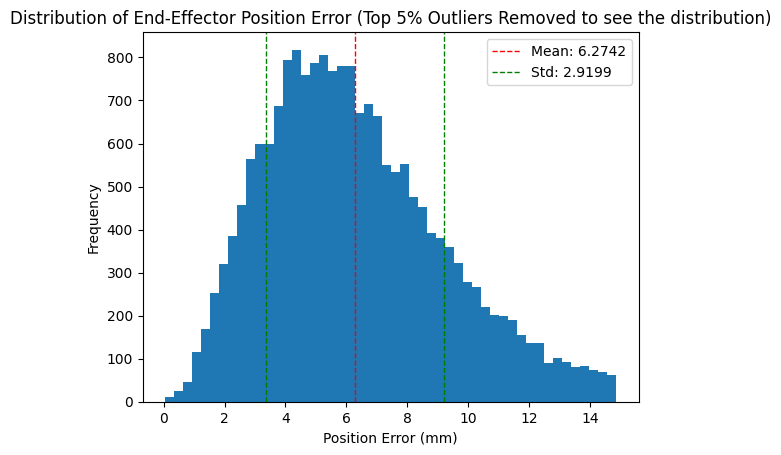

In [ ]:
pos_error_vec=Tsb_pred[:,:3,3]-Tsb[:,:3,3]
pos_error=torch.linalg.norm(pos_error_vec,dim=1)
import matplotlib.pyplot as plt

# Remove outliers for better visualization by keeping values below the 95th percentile.
# These outliers will be investigated later.
threshold = torch.quantile(pos_error, 0.95)
pos_error_filtered = pos_error[pos_error < threshold]

plt.hist(pos_error_filtered.cpu().detach().numpy()*1e3, bins=50) # Adjusted bins for clearer view

mean_error = pos_error_filtered.mean().item()*1000
std_error = pos_error_filtered.std().item()*1000

plt.axvline(mean_error, color='r', linestyle='dashed', linewidth=1, label=f'Mean: {mean_error:.4f}')
plt.axvline(mean_error + std_error, color='g', linestyle='dashed', linewidth=1, label=f'Std: {std_error:.4f}')
plt.axvline(mean_error - std_error, color='g', linestyle='dashed', linewidth=1)

plt.title('Distribution of End-Effector Position Error (Top 5% Outliers Removed to see the distribution)')
plt.xlabel('Position Error (mm)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

#modified IKinSpace from modern-robotics added the number of iteration up to convergence to the output


#

In [ ]:
!pip install modern-robotics
import numpy as np
import modern_robotics as mr
def IKinSpace_with_iters(Slist, M, T, thetalist0, eomg, ev):
    thetalist = np.array(thetalist0).copy()
    i = 0
    maxiterations = 50
    Tsb = mr.FKinSpace(M,Slist, thetalist)
    Vs = np.dot(mr.Adjoint(Tsb),mr.se3ToVec(mr.MatrixLog6(np.dot(mr.TransInv(Tsb), T))))
    err = np.linalg.norm([Vs[0], Vs[1], Vs[2]]) > eomg or np.linalg.norm([Vs[3], Vs[4], Vs[5]]) >  ev
    while err and i < maxiterations:
        thetalist = thetalist + np.dot(np.linalg.pinv(mr.JacobianSpace(Slist,thetalist)), Vs)
        i = i + 1
        Tsb = mr.FKinSpace(M, Slist, thetalist)
        Vs = np.dot(mr.Adjoint(Tsb), \
                    mr.se3ToVec(mr.MatrixLog6(np.dot(mr.TransInv(Tsb), T))))
        err = np.linalg.norm([Vs[0], Vs[1], Vs[2]]) > eomg \
              or np.linalg.norm([Vs[3], Vs[4], Vs[5]]) > ev
    return (thetalist, not err,i)

In [ ]:
from ik.kinematics.fk import _M_HOME_np,_Slist_np,FK_batch_full,FK
from ik.data.pipeline import sample_q
!pip install tqdm
from tqdm import tqdm
q_IK=[]
itter_IK=[]
converged=[]
Tsbs=FK_batch_full(val_ds.q1)
for X, _, q1, xd in tqdm(val_ds):
  q_hot_start=model(X.to(DEVICE))
  q_hot_start=q_hot_start*val_ds.scaler_Y[1].to(DEVICE)+val_ds.scaler_Y[0].to(DEVICE)
  q_hot_start=q_hot_start.detach().cpu().numpy()
  Tsb=FK(q1.cpu().numpy())

  q,converge,itter=IKinSpace_with_iters(_Slist_np,_M_HOME_np,Tsb,q_hot_start,0.001,0.001)
  q_IK.append(q)
  itter_IK.append(itter)
  converged.append(converge)

  0%|          | 0/20000 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/modern_robotics/core.py:397: RuntimeWarning: invalid value encountered in arccos
  theta = np.arccos((np.trace(R) - 1) / 2.0)
  2%|▏         | 467/20000 [00:43<30:27, 10.69it/s]


KeyboardInterrupt: 

In [ ]:
sum(np.array(itter_IK)==50)/len(itter_IK)

np.float64(0.26124197002141325)

In [ ]:
itter_IK

[24,
 31,
 37,
 21,
 28,
 50,
 38,
 36,
 21,
 30,
 48,
 19,
 43,
 50,
 2,
 29,
 43,
 18,
 50,
 50,
 50,
 49,
 1,
 49,
 42,
 41,
 50,
 50,
 35,
 23,
 16,
 30,
 28,
 50,
 38,
 32,
 38,
 33,
 42,
 50,
 28,
 2,
 28,
 1,
 8,
 39,
 50,
 44,
 5,
 49,
 45,
 8,
 41,
 34,
 30,
 1,
 46,
 50,
 39,
 12,
 39,
 1,
 30,
 41,
 28,
 50,
 33,
 38,
 36,
 2,
 28,
 50,
 31,
 2,
 35,
 50,
 49,
 45,
 50,
 40,
 46,
 50,
 22,
 50,
 23,
 27,
 38,
 46,
 50,
 35,
 47,
 31,
 30,
 50,
 46,
 8,
 26,
 24,
 4,
 37,
 41,
 50,
 28,
 35,
 50,
 36,
 8,
 27,
 50,
 1,
 45,
 43,
 50,
 50,
 50,
 50,
 50,
 18,
 48,
 40,
 50,
 29,
 28,
 3,
 50,
 26,
 50,
 39,
 2,
 49,
 50,
 50,
 43,
 50,
 50,
 50,
 50,
 35,
 50,
 50,
 50,
 40,
 21,
 14,
 50,
 33,
 39,
 50,
 29,
 20,
 50,
 38,
 8,
 41,
 8,
 42,
 50,
 25,
 50,
 43,
 48,
 50,
 50,
 32,
 50,
 46,
 23,
 50,
 1,
 41,
 50,
 33,
 47,
 33,
 15,
 30,
 50,
 24,
 33,
 50,
 48,
 36,
 42,
 43,
 50,
 48,
 20,
 34,
 41,
 50,
 48,
 44,
 12,
 46,
 50,
 45,
 50,
 50,
 3,
 5,
 32,
 2,
 44,
 6,
 31,

In [ ]:
Slist_np = np.array([
    [0,  0,  1,  0,        0,       0      ],  # joint 1 (waist)
    [0,  1,  0, -0.12705,  0,       0      ],  # joint 2 (shoulder)
    [0,  1,  0, -0.42705,  0,       0.05955],  # joint 3 (elbow)
    [1,  0,  0,  0,        0.42705, 0      ],  # joint 4 (forearm roll)
    [0,  1,  0, -0.42705,  0,       0.35955],  # joint 5 (wrist angle)
    [1,  0,  0,  0,        0.42705, 0      ],  # joint 6 (wrist rotate)
]).T  # shape (6, 6)

M_HOME_np = np.array([
    [1, 0, 0, 0.536494],
    [0, 1, 0, 0       ],
    [0, 0, 1, 0.42705 ],
    [0, 0, 0, 1       ],
], dtype=float)


In [ ]:
from ik.kinematics.fk import FK_batch_full,FK
!pip install tqdm
from tqdm import tqdm
q_IK_no_hot=[]
itter_IK_no_hot=[]
converged_no_hot=[]
Tsbs=FK_batch_full(val_ds.q1)
for X, _, q1, xd in tqdm(val_ds):
  #q_hot_start=model(X.to(DEVICE))
  #q_hot_start=q_hot_start*val_ds.scaler_Y[1].to(DEVICE)+val_ds.scaler_Y[0].to(DEVICE)
  #q_hot_start=q_hot_start.detach().cpu().numpy()
  Tsb=FK(q1.cpu().numpy())

  q,converge,itter=IKinSpace_with_iters(Slist_np,M_HOME_np,Tsb,sample_q(1),0.001,0.001)
  q_IK_no_hot.append(q)
  itter_IK_no_hot.append(itter)
  converged_no_hot.append(converge)

  1%|          | 230/20000 [00:07<10:53, 30.26it/s]


KeyboardInterrupt: 

In [ ]:
sum(np.array(itter_IK_no_hot)==50)/len(itter_IK_no_hot)

np.float64(0.4608695652173913)

In [ ]:
for X, _, q1, xd in val_loader:
    q_pred = model(X.to(DEVICE)) * val_ds.scaler_Y[1].to(DEVICE) + val_ds.scaler_Y[0].to(DEVICE)
    T_pred   = FK_batch_full(q_pred)
    T_target = FK_batch_full(q1)
    pos = torch.norm(T_pred[:, :3, 3].to(DEVICE) - T_target[:, :3, 3].to(DEVICE), dim=1).mean()
    rot = torch.norm(T_pred[:, :3, :3].to(DEVICE) - T_target[:, :3, :3].to(DEVICE), dim=(1,2)).mean()
    print(f"pos: {pos:.4f} m | rot: {rot:.4f}")
    break


pos: 0.0021 m | rot: 2.0845


array([[1.      , 0.5     , 0.7     , 0.536494],
       [0.      , 1.      , 0.      , 0.      ],
       [0.      , 0.      , 0.7     , 0.42705 ],
       [0.      , 0.      , 0.      , 1.      ]])

#line trajectory to compare NR with cold start Vs hot start

You can see `with grad_mode(False):` used in the cell below, for example, when performing inverse kinematics calculations along the trajectory, as gradient computation is not needed there.

In [ ]:
import numpy as np
z_line = 0.6
p_line_start = np.array([-0.35, 0.0, z_line])
p_line_end   = np.array([ 0.35, 0.0, z_line])

q_init = np.zeros(6)
points=np.linspace(p_line_start,p_line_end,100)
T_sds = []
for p in points:
    T = np.eye(4)
    T[:3, 3] = p  # Set the translational part
    T_sds.append(T)

i=[]
T_list=[]
q_final=[]
pos_error=[]
q_final_hot_start=[]
iter_predict_hot_start=[]
with torch.no_grad():
  for k in range(1):
    T=T_sds[k]
    T=kk
    T_tensor=torch.tensor(np.concatenate([T[:3,3].flatten(),T[:2,:3].flatten()]),dtype=torch.float).to(DEVICE)
    q_predict_hot_start=model((T_tensor-val_ds.scaler_X[0].to(DEVICE))/val_ds.scaler_X[1].to(DEVICE))
    q_predict_hot_start=q_predict_hot_start*val_ds.scaler_Y[1].to(DEVICE)+val_ds.scaler_Y[0].to(DEVICE)
    q_predict_hot_start=q_predict_hot_start.detach().cpu().numpy()
    q_predict,_,iter_predict=IKinSpace_with_iters(Slist=Slist_np, M=M_HOME_np, T=T, thetalist0=q_predict_hot_start
                                                  ,eomg=1e-3,ev=1e-3)
    q_final_hot_start.append(q_predict)
    iter_predict_hot_start.append(iter_predict)

    q_nr,_,iter_nr=IKinSpace_with_iters(Slist=Slist_np, M=M_HOME_np, T=T, thetalist0=q_init,eomg=1e-3,ev=1e-3)
    q_init=q_nr
    T_final=FK(q_nr)
    T_list.append(T_final)
    pos_error.append(np.linalg.norm(T_final[0:3,3]-T[0:3,3]))
    i.append(iter_nr)
    q_final.append(q_nr)

In [ ]:
iter_predict

14

In [ ]:
i
iter_predict_hot_start

[14]

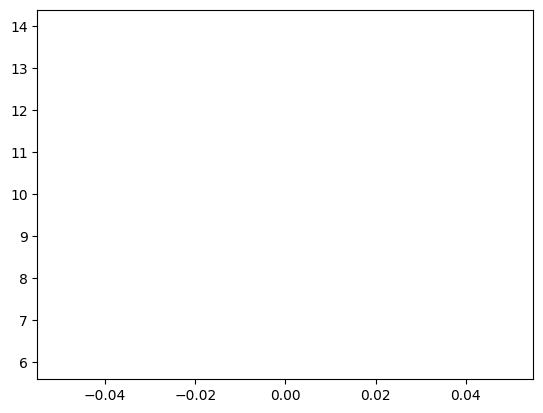

In [ ]:
plt.plot(i)
plt.plot(iter_predict_hot_start)

In [ ]:
iter_nr

50

In [ ]:
from ik.kinematics.fk import _M_HOME_np,_Slist_np,FK_batch_full,FK
from ik.data.pipeline import sample_q
!pip install tqdm
from tqdm import tqdm
q_IK=[]
itter_IK=[]
converged=[]
Tsbs=FK_batch_full(val_ds.q1)
for X, _, q1, xd in tqdm(val_ds):
  q_hot_start=model(X.to(DEVICE))
  q_hot_start=q_hot_start*val_ds.scaler_Y[1].to(DEVICE)+val_ds.scaler_Y[0].to(DEVICE)
  q_hot_start=q_hot_start.detach().cpu().numpy()
  Tsb=FK(q1.cpu().numpy())

  q,converge,itter=IKinSpace_with_iters(_Slist_np,_M_HOME_np,Tsb,q_hot_start,0.001,0.001)
  q_IK.append(q)
  itter_IK.append(itter)
  converged.append(converge)

In [ ]:
import torch.nn as nn
def evaluate_and_return_loss(
    model: nn.Module,
    loader: DataLoader,
    device,
    scaler_Y: list,
    hot_start: bool = False,
    lambda_rot: float = 1.0,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """Return per-sample (pos_losses, rot_losses, total_losses) as 1-D tensors.
    rot_losses is zeros when hot_start=False. Prints mean of all three."""
    model.eval()
    Y_mean, Y_std = scaler_Y[0].to(device), scaler_Y[1].to(device)
    all_pos, all_rot, all_total = [], [], []

    with torch.no_grad():
        for X, _, q1, xd in loader:
            X, q1, xd = X.to(device), q1.to(device), xd.to(device)

            q_pred = model(X) * Y_std + Y_mean
            if not hot_start:
                q_pred = q1 + q_pred

            if hot_start:
                T_pred   = FK_batch_full(q_pred)
                T_target = FK_batch_full(q1)
                pos_loss = torch.norm(T_pred[:, :3, 3] - T_target[:, :3, 3], dim=1)
                rot_loss = torch.norm(T_pred[:, :3, :3] - T_target[:, :3, :3], dim=(1, 2))
                total    = pos_loss + lambda_rot * rot_loss
            else:
                pos_loss = torch.norm(FK_batch(q_pred) - xd, dim=1)
                rot_loss = torch.zeros_like(pos_loss)
                total    = pos_loss

            all_pos.append(pos_loss)
            all_rot.append(rot_loss)
            all_total.append(total)

    pos_losses   = torch.cat(all_pos)
    rot_losses   = torch.cat(all_rot)
    total_losses = torch.cat(all_total)

    print(
        f"mean pos loss:   {pos_losses.mean().item():.4f} | "
        f"mean rot loss:   {rot_losses.mean().item():.4f} | "
        f"mean total loss: {total_losses.mean().item():.4f}"
    )

    return pos_losses, rot_losses, total_losses

In [ ]:
evaluate_and_return_loss(
    model=model,
    loader=val_loader,


    device=DEVICE,
    scaler_Y=val_ds.scaler_Y,
    hot_start=True,
    lambda_rot=0.0092/2.0272

)

mean pos loss:   0.0163 | mean rot loss:   0.1968 | mean total loss: 0.0172


(tensor([0.0068, 0.0055, 0.0213,  ..., 0.0124, 0.0162, 0.0108]),
 tensor([0.1410, 0.0755, 2.7441,  ..., 0.0690, 0.0506, 0.1029]),
 tensor([0.0074, 0.0059, 0.0338,  ..., 0.0128, 0.0165, 0.0113]))

In [ ]:
import numpy as np

def generate_euclidean_q_targets(q_init):
    """
    Generates 30 targets per q_init based on Euclidean distance tiers in joint space.
    Optimized for ML training sets with mixed transformation scales.

    Args:
        q_init: np.array of shape (n, 6) in radians
    Returns:
        q_init_expanded: (30*n, 6)
        q_dest: (30*n, 6)
    """
    n = q_init.shape[0]
    samples_per_tier = 10
    total_samples = 30

    # 1. Physical Constraints (Radians)
    JOINT_LIMITS = np.deg2rad([
        [-180, 180], [-101, 101], [-101, 92],
        [-180, 180], [-107, 130], [-180, 180]
    ])
    low_lim, high_lim = JOINT_LIMITS[:, 0], JOINT_LIMITS[:, 1]

    # 2. Define Euclidean Distance Tiers (Degrees -> Radians)
    # We want the total L2 norm of the change to fall within these ranges
    tiers_deg = np.array([
        [1, 3],    # Close
        [5, 15],   # Further
        [15, 30]   # Far
    ])
    tiers_rad = np.deg2rad(tiers_deg)

    # 3. Expand q_init to (n, 30, 6)
    q_expanded = np.repeat(q_init[:, np.newaxis, :], total_samples, axis=1)

    # 4. Generate Random Directions (Unit Vectors)
    # Sampling from a normal distribution and normalizing gives uniform directions in 6D
    directions = np.random.randn(n, total_samples, 6)
    directions /= np.linalg.norm(directions, axis=2, keepdims=True)

    # 5. Generate Random Magnitudes for each tier
    # Logic: For each n, generate 10 samples for each of the 3 tiers
    mags_list = []
    for low, high in tiers_rad:
        mags_list.append(np.random.uniform(low, high, size=(n, samples_per_tier)))

    # Concatenate tiers and add a dimension for broadcasting: (n, 30, 1)
    magnitudes = np.concatenate(mags_list, axis=1)[:, :, np.newaxis]

    # 6. Compute Destinations: q_dest = q_init + (direction * magnitude)
    q_dest = q_expanded + (directions * magnitudes)

    # 7. Safety Clip to Joint Limits
    q_dest = np.clip(q_dest, low_lim, high_lim)

    # Flatten back to 2D arrays for output
    return q_expanded.reshape(-1, 6), q_dest.reshape(-1, 6)

31/3/26 code done in collab later will be passed to ik library and then to git just easier to do it locally for me here

#generating DataSet

In [ ]:
from ik.data.pipeline import sample_q
q_init,q_target=generate_euclidean_q_targets(sample_q(10000))

NameError: name 'generate_euclidean_q_targets' is not defined

In [ ]:
from ik.kinematics.fk import FK_batch_full
import torch
q_init_tensor=torch.tensor(q_init,dtype=torch.float)
q_target_tensor=torch.tensor(q_target,dtype=torch.float)
T_target=FK_batch_full(q_target_tensor)
P_target=T_target[:,:3,3].numpy()
R6_target=T_target[:,:2,:3].numpy()




In [ ]:
SAVE_DIR='/content/drive/MyDrive/inverse_kinematics/pos_rot_qinit'
#save_raw(SAVE_DIR,q_init,q_target,P_target,R6_target)
#split_and_save(SAVE_DIR)
q_init_train, q_target_train, P_target_train, R6_target_train=load_split(SAVE_DIR,'train')

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/inverse_kinematics/pos_rot_qinit/q1_train.npy'

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

# Define global constants for normalization
JOINT_LIMITS = np.deg2rad([
    [-180, 180], [-101, 101], [-101, 92],
    [-180, 180], [-107, 130], [-180, 180]
])

def save_raw(
    save_dir: str,
    q_init: np.ndarray,
    q_target: np.ndarray,
    P_target: np.ndarray,
    R6_target: np.ndarray,
    normalize: bool = True
) -> None:
    """
    Saves the raw generated data.
    Applies MinMaxScaler to [-1, 1] for q_init and q_target if normalize=True.
    """

    # Using the naming convention expected by your load_split function
    np.save(f"{save_dir}/q_init.npy", q_init.astype(np.float32))
    np.save(f"{save_dir}/q_target.npy", q_target.astype(np.float32))
    np.save(f"{save_dir}/P_target.npy", P_target.astype(np.float32))
    np.save(f"{save_dir}/R6_target.npy", R6_target.astype(np.float32))

    print(f"Saved raw data to {save_dir}")

def split_and_save(
    save_dir: str,
    test_size: float = 0.20,
    val_fraction: float = 0.50,
    random_state: int = 42,
) -> None:
    """
    Loads raw arrays, splits into train/val/test, and saves with split suffixes.
    """
    # Load the base raw files
    q_init = np.load(f"{save_dir}/q_init.npy")
    q_target = np.load(f"{save_dir}/q_target.npy")
    P_target = np.load(f"{save_dir}/P_target.npy")
    R6_target = np.load(f"{save_dir}/R6_target.npy")

    indices = np.arange(len(q_init))

    # First split: Train vs Temp (Val + Test)
    idx_train, idx_temp = train_test_split(indices, test_size=test_size, random_state=random_state)
    # Second split: Val vs Test
    idx_val, idx_test = train_test_split(idx_temp, test_size=1 - val_fraction, random_state=random_state)

    splits = {"train": idx_train, "val": idx_val, "test": idx_test}

    for name, idx in splits.items():
        np.save(f"{save_dir}/q_init_{name}.npy", q_init[idx])
        np.save(f"{save_dir}/q_target_{name}.npy", q_target[idx])
        np.save(f"{save_dir}/P_target_{name}.npy", P_target[idx])
        np.save(f"{save_dir}/R6_target_{name}.npy", R6_target[idx])
        print(f"{name:>5}: {len(idx):>7,} samples")

def load_split(save_dir: str, split: str) -> tuple:
    """
    Loads one specific split. Returns all arrays as float32.
    """
    q_init = np.load(f"{save_dir}/q_init_{split}.npy").astype(np.float32)
    q_target = np.load(f"{save_dir}/q_target_{split}.npy").astype(np.float32)
    P_target = np.load(f"{save_dir}/P_target_{split}.npy").astype(np.float32)
    R6_target = np.load(f"{save_dir}/R6_target_{split}.npy").astype(np.float32)

    return q_init, q_target, P_target, R6_target

In [ ]:
def load_split2(save_dir: str, split: str) -> tuple:
    """
    Loads one specific split. Returns all arrays as float32.
    """
    q_init = np.load(f"{save_dir}/q_init_{split}.npy").astype(np.float32)
    q_target = np.load(f"{save_dir}/q_target_{split}.npy").astype(np.float32)
    P_target = np.load(f"{save_dir}/P_target_{split}.npy").astype(np.float32)
    R6_target = np.load(f"{save_dir}/R6_target_{split}.npy").astype(np.float32).reshape(q_init.shape[0], -1)

    return q_init, q_target, P_target, R6_target

import numpy as np
import torch
from torch.utils.data import Dataset

from ik.data.pipeline import load_split


class IKDataset2(Dataset):


  def __init__(
      self,

      split: str,
      save_dir: str,
      hot_start: bool = False,
      MinMax_X: list | None = None,
      MinMax_Y: list | None = None,
  ):

    q_init,q_target,P_target,R6_target=load_split2(save_dir,split)

    y=q_target.copy()
    X=np.concatenate([R6_target,P_target,q_init],axis=1)
    if MinMax_X is None:
      self.MinMax_Y=[y.min(axis=0),y.max(axis=0)]
      self.MinMax_X=[X.min(axis=0),X.max(axis=0)]
    else:
      self.MinMax_Y=MinMax_Y
      self.MinMax_X=MinMax_X

    self.y=(y-self.MinMax_Y[0])/(self.MinMax_Y[1]-self.MinMax_Y[0])
    self.y=(self.y*2)-1
    self.X=(X-self.MinMax_X[0])/(self.MinMax_X[1]-self.MinMax_X[0])
    self.X=(self.X*2)-1
    self.q_init=q_init
    self.q_target=q_target
    self.P_target=P_target
    self.R6_target=R6_target




  def __len__(self) -> int:
      return len(self.X)

  def __getitem__(self, idx):
      return self.X[idx], self.y[idx]

In [ ]:
R6_target_train.reshape(240000,6).shape

(240000, 6)

In [ ]:
train_ds=IKDataset2('train',SAVE_DIR)
train_ds

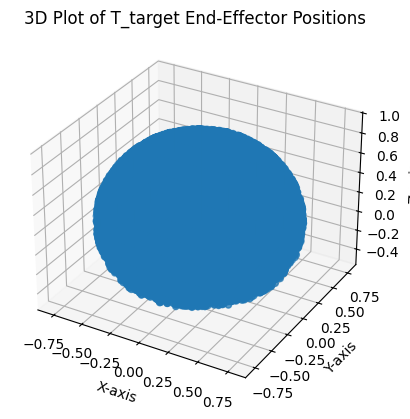

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Extract the x, y, z coordinates from T_target
x = T_target[:, 0, 3].numpy()
y = T_target[:, 1, 3].numpy()
z = T_target[:, 2, 3].numpy()

# Create a 3D plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Scatter plot the points
ax.scatter(x, y, z)

# Set labels
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.set_zlabel('Z-axis')
ax.set_title('3D Plot of T_target End-Effector Positions')

plt.show()